# 🏈 Fantasy Football Draft Analysis (2024–2025)
*Justin McKendry · August 2025*

---

## 📚 Project Overview

This notebook uses a linear regression algorithm to create a draft score using the projected points, projected vorp, and average points last year

**Key Metrics:**
- 📈 Projected Points
- 🎯 Projected VORP
- 💥 Average Points Last Year

---

## 🧪 4. Draft Board

### 🔍 Purpose
Take the data from the SQL Database and create a draft board to be displayed on the front end

In [349]:
import pandas as pd 
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression

from numpy.polynomial.polynomial import Polynomial
import numpy as np
import math
import plotly.express as px
import scipy.stats as stats


# Visualise the distribution of comments per post
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import sqlite3
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))

from utils import get_league_data, get_all_player_stats, save_to_data_raw, process_projections
from config import NEXT_SEASON, CURRENT_SEASON
# --- Configuration for Jupyter ---
# The following magic command is for Jupyter notebooks to render plots inline.
# It should be commented out when running as a standalone script.
%config InlineBackend.figure_formats = ['svg']


In [350]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

In [351]:
def calculate_proj_vorp_past_season(engine, year):
    query = """
    WITH proj_qb_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'QB' AND a.pos_rank BETWEEN 15 AND 18
    ),
    proj_rb_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'RB' AND a.pos_rank BETWEEN 29 AND 32
    ),
    proj_wr_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'WR' AND a.pos_rank BETWEEN 29 AND 32
    ),
    proj_te_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'TE' AND a.pos_rank BETWEEN 10 AND 13
    ),
    proj_k_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'K' AND a.pos_rank BETWEEN 15 AND 18
    ),
    proj_dst_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'DST' AND a.pos_rank BETWEEN 15 AND 18
    ),

    qb_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'QB' AND ps.posRank BETWEEN 15 AND 18
    ),
    rb_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'RB' AND ps.posRank BETWEEN 29 AND 32
    ),
    wr_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'WR' AND ps.posRank BETWEEN 29 AND 32
    ),
    te_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'TE' AND ps.posRank  BETWEEN 10 AND 13
    ),
    k_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'K' AND ps.posRank BETWEEN 15 AND 18
    ),
    dst_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM players_stats ps
        JOIN average_draft_position a
            ON ps.player_id = a.player_id AND ps.year = a.year
        WHERE a.position = 'DST' AND ps.posRank BETWEEN 15 AND 18
    )

    SELECT 
        ps.player_id,
        ps.player_name,
        ps.year,
        ps.projected_points,
        prevp.avg_points AS avg_points_ly,
        ROUND(
            CASE
                WHEN a.position = 'QB' THEN ps.projected_points - (SELECT ppg FROM proj_qb_replacement)
                WHEN a.position = 'RB' THEN ps.projected_points - (SELECT ppg FROM proj_rb_replacement)
                WHEN a.position = 'WR' THEN ps.projected_points - (SELECT ppg FROM proj_wr_replacement)
                WHEN a.position = 'TE' THEN ps.projected_points - (SELECT ppg FROM proj_te_replacement)
                WHEN a.position = 'K' THEN ps.projected_points - (SELECT ppg FROM proj_k_replacement)
                WHEN a.position = 'DST' THEN ps.projected_points - (SELECT ppg FROM proj_dst_replacement)
                ELSE 0
            END
        , 2) AS proj_vorp,

        ROUND(
            CASE
                WHEN a.position = 'QB' THEN ps.points - (SELECT ppg FROM qb_replacement)
                WHEN a.position = 'RB' THEN ps.points - (SELECT ppg FROM rb_replacement)
                WHEN a.position = 'WR' THEN ps.points - (SELECT ppg FROM wr_replacement)
                WHEN a.position = 'TE' THEN ps.points - (SELECT ppg FROM te_replacement)
                WHEN a.position = 'K' THEN ps.points - (SELECT ppg FROM k_replacement)
                WHEN a.position = 'DST' THEN ps.points - (SELECT ppg FROM dst_replacement)
                ELSE 0
            END
        , 2) AS actual_vorp,
        ps.points
    FROM players_stats ps
    LEFT JOIN players_stats prevp
        ON prevp.player_id = ps.player_id
        AND prevp.year = ps.year - 1
    LEFT JOIN average_draft_position a
        ON ps.year = a.year
    AND (
            (ps.player_id = a.player_id)
        OR (a.player_id IS NULL AND ps.player_name = a.player_name)
    )
    ORDER BY proj_vorp DESC
    """
    return pd.read_sql(query, engine, params={"year": year})

df_regression = calculate_proj_vorp_past_season(engine, 2024)
df = df.fillna(0)
df_regression.head(25)

,player_id,player_name,year,projected_points,avg_points_ly,proj_vorp,actual_vorp,points
0,3117251,Christian McCaffrey,2024,334.00,19.31,234.04,-45.35,43.0
1,4241389,CeeDee Lamb,2024,315.50,15.00,202.29,148.63,253.0
2,3918298,Josh Allen,2022,372.83,22.65,202.26,159.33,380.0
3,4430807,Bijan Robinson,2024,292.24,10.35,192.28,238.65,327.0
4,4427366,Breece Hall,2024,287.83,11.65,187.87,139.65,228.0
5,3116406,Tyreek Hill,2024,297.81,15.62,184.60,104.63,209.0
6,3139477,Patrick Mahomes,2022,350.30,20.59,179.73,178.33,399.0
7,4362628,Ja'Marr Chase,2024,288.11,9.88,174.90,289.63,394.0
8,4242335,Jonathan Taylor,2022,272.68,18.82,172.72,22.65,111.0
9,4374302,Amon-Ra St. Brown,2024,282.70,12.75,169.49,205.63,310.0


In [352]:
df_regression['avg_points_ly'] = df_regression['avg_points_ly'].fillna(0)


In [353]:
X = df_regression[['projected_points', 'proj_vorp', 'avg_points_ly']]
y = df_regression['actual_vorp']   # actual outcomes

# Fit linear regression
model = LinearRegression().fit(X, y)

# coefficients (weights)
weights = model.coef_
intercept = model.intercept_

print("Intercept:", intercept)
print("Weights:", dict(zip(X.columns, weights)))
model

Intercept: 4.500412620408739
Weights: {'projected_points': np.float64(-0.13304233563389029), 'proj_vorp': np.float64(0.6155189735157209), 'avg_points_ly': np.float64(1.827462791915489)}


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [354]:
w = {
    "projected_points": -0.13089427887306748,
    "proj_vorp": 0.614937424164257,
    "avg_points_ly": 1.8333815073478639,
    "intercept": 3.6498622964280063,
}

df_regression["draft_score_lr"] = (
    w["intercept"]
    + w["projected_points"] * df_regression["projected_points"]
    + w["proj_vorp"]        * df_regression["proj_vorp"]
    + w["avg_points_ly"]    * df_regression["avg_points_ly"]
)
df_regression = df_regression.sort_values("draft_score_lr", ascending=False)
df_regression


,player_id,player_name,year,projected_points,avg_points_ly,proj_vorp,actual_vorp,points,draft_score_lr
0,3117251,Christian McCaffrey,2024,334.00,19.31,234.04,-45.35,43.0,139.253725
2,3918298,Josh Allen,2022,372.83,22.65,202.26,159.33,380.0,120.751883
1,4241389,CeeDee Lamb,2024,315.50,15.00,202.29,148.63,253.0,114.249131
8,4242335,Jonathan Taylor,2022,272.68,18.82,172.72,22.65,111.0,108.673842
5,3116406,Tyreek Hill,2024,297.81,15.62,184.60,104.63,209.0,106.823105
...,...,...,...,...,...,...,...,...,...
2372,3886812,Jake Browning,2023,0.00,0.00,-170.57,-82.67,138.0,-101.240014
2371,4432577,C.J. Stroud,2023,0.00,0.00,-170.57,42.33,263.0,-101.240014
2432,4360698,Joe Milton III,2024,0.00,0.00,-170.57,-202.67,18.0,-101.240014
2390,4429084,Anthony Richardson,2023,0.00,0.00,-170.57,-151.67,69.0,-101.240014


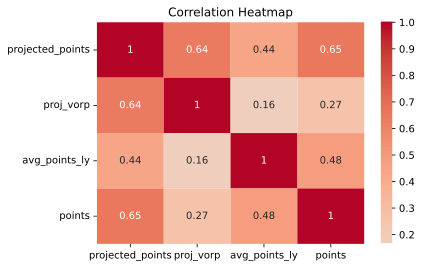

In [355]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_regression[['projected_points','proj_vorp','avg_points_ly','points']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()


In [356]:
def calculate_proj_vorp_this_season(engine, year):
    query = """
    WITH qb_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM next_season_projections pr
        JOIN average_draft_position a
            ON pr.player_id = a.player_id AND pr.year = a.year
        WHERE a.position = 'QB' AND a.pos_rank BETWEEN 15 AND 18
    ),
    rb_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM next_season_projections pr
        JOIN average_draft_position a
            ON pr.player_id = a.player_id AND pr.year = a.year
        WHERE a.position = 'RB' AND a.pos_rank BETWEEN 29 AND 32
    ),
    wr_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM next_season_projections pr
        JOIN average_draft_position a
            ON pr.player_id = a.player_id AND pr.year = a.year
        WHERE a.position = 'WR' AND a.pos_rank BETWEEN 29 AND 32
    ),
    te_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM next_season_projections pr
        JOIN average_draft_position a
            ON pr.player_id = a.player_id AND pr.year = a.year
        WHERE a.position = 'TE' AND a.pos_rank BETWEEN 10 AND 13
    ),
    k_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM next_season_projections pr
        JOIN average_draft_position a
            ON pr.player_id = a.player_id AND pr.year = a.year
        WHERE a.position = 'K' AND a.pos_rank BETWEEN 15 AND 18
    ),
    dst_replacement AS (
        SELECT AVG(projected_points) AS ppg 
        FROM next_season_projections pr
        JOIN average_draft_position a
            ON pr.player_id = a.player_id AND pr.year = a.year
        WHERE a.position = 'DST' AND a.pos_rank BETWEEN 15 AND 18
    )

    SELECT 
        pr.player_id,
        pr.player_name,
        a.position,
        a.pos_rank,
        pr.projected_points,
        a.avg AS adp,
        ROUND(
            CASE
                WHEN a.position = 'QB' THEN pr.projected_points - (SELECT ppg FROM qb_replacement)
                WHEN a.position = 'RB' THEN pr.projected_points - (SELECT ppg FROM rb_replacement)
                WHEN a.position = 'WR' THEN pr.projected_points - (SELECT ppg FROM wr_replacement)
                WHEN a.position = 'TE' THEN pr.projected_points - (SELECT ppg FROM te_replacement)
                WHEN a.position = 'K' THEN pr.projected_points - (SELECT ppg FROM k_replacement)
                WHEN a.position = 'DST' THEN pr.projected_points - (SELECT ppg FROM dst_replacement)
                ELSE 0
            END
        , 2) AS proj_vorp
    FROM next_season_projections pr
    LEFT JOIN average_draft_position a
        ON pr.year = a.year
    AND (
            (pr.player_id = a.player_id)
        OR (a.player_id IS NULL AND pr.player_name = a.player_name)
    )
    ORDER BY proj_vorp DESC
    """
    return pd.read_sql(query, engine, params={"year": year})


In [357]:
projected_vorp = calculate_proj_vorp_this_season(engine, 2025)
projected_vorp[projected_vorp['position'] == 'RB'].head(10)


,player_id,player_name,position,pos_rank,projected_points,adp,proj_vorp
0,4430807,Bijan Robinson,RB,2.0,334.68,3.0,134.55
1,3929630,Saquon Barkley,RB,1.0,324.30,2.8,124.17
2,3117251,Christian McCaffrey,RB,4.0,320.98,9.4,120.85
3,4429795,Jahmyr Gibbs,RB,3.0,315.97,4.6,115.84
7,4429160,De'Von Achane,RB,7.0,304.36,12.8,104.23
9,4890973,Ashton Jeanty,RB,5.0,296.82,9.6,96.69
13,4242335,Jonathan Taylor,RB,9.0,290.38,20.4,90.25
17,4596448,Bucky Irving,RB,10.0,280.98,21.2,80.85
18,4047365,Josh Jacobs,RB,8.0,280.68,17.4,80.55
19,4362238,Chase Brown,RB,12.0,280.24,27.6,80.11


In [358]:
query = """ 
    SELECT 
        pr.player_id,
        pr.player_name,
        d.roundPickNumber AS actual_pick,
        a.avg AS market_value,
        (d.overallPickNumber - a.avg) AS draft_delta,
        a.position,
        d.year
        
    FROM next_season_projections pr 
    Left JOIN drafts d 
        ON pr.player_id = d.player_id
    Left JOIN average_draft_position a
        ON pr.player_id = a.player_id AND d.year = a.year

"""

draft_delta = pd.read_sql(query, engine)
draft_delta = draft_delta.groupby(["player_name","player_id"]).agg(
    avg_draft_delta=("draft_delta", "mean"),
    n_drafts=("draft_delta", "count")
)
draft_delta['avg_draft_delta'] = draft_delta['avg_draft_delta'].round(2)
draft_delta = draft_delta.fillna(0)
draft_delta

,,avg_draft_delta,n_drafts
player_name,player_id,,
49ers D/ST,-16025,12.17,3
A.J. Brown,4047646,-6.77,3
AJ Barner,4576297,0.00,0
AJ Dillon,4239934,9.75,2
Aaron Jones Sr.,3042519,4.17,3
...,...,...,...
Zack Moss,4035676,18.30,1
Zamir White,4361777,-4.30,1
Zane Gonzalez,3043234,0.00,0


In [359]:
# positive value means that they are usually drafted lower than their market value i.e. undervalued
# negative value means that they are drafted higher than their market value i.e. overvalued
df = pd.merge(projected_vorp,draft_delta, on=['player_name'])
df.sort_values(by='proj_vorp',ascending=False).head(42)


,player_id,player_name,position,pos_rank,projected_points,adp,proj_vorp,avg_draft_delta,n_drafts
0,4430807,Bijan Robinson,RB,2.0,334.68,3.0,134.55,4.10,2
1,3929630,Saquon Barkley,RB,1.0,324.30,2.8,124.17,2.50,3
2,3117251,Christian McCaffrey,RB,4.0,320.98,9.4,120.85,0.17,3
3,4429795,Jahmyr Gibbs,RB,3.0,315.97,4.6,115.84,1.15,2
4,4432665,Brock Bowers,TE,1.0,259.74,18.6,112.96,-13.70,1
5,4361307,Trey McBride,TE,2.0,258.49,26.0,111.71,18.70,1
6,4362628,Ja'Marr Chase,WR,1.0,337.69,1.0,110.84,0.83,3
7,4429160,De'Von Achane,RB,7.0,304.36,12.8,104.23,-3.70,1
8,4262921,Justin Jefferson,WR,2.0,323.61,4.6,96.76,0.90,3
9,4890973,Ashton Jeanty,RB,5.0,296.82,9.6,96.69,0.00,0


In [360]:
query = """ 
    SELECT 
        pr.player_id,
        pr.player_name,
        ps.games_played AS games_played_last_year,
        ps.points AS points_last_year,
        ps.avg_points AS avg_last_year

        FROM next_season_projections pr
        LEFT JOIN players_stats ps
            ON pr.player_id = ps.player_id AND (pr.year-1) = ps.year
        
"""
df_games = pd.read_sql(query, engine)
df_games['games_played_last_year'] = df_games['games_played_last_year'].fillna(0)
df_games['points_last_year'] = df_games['points_last_year'].fillna(0)
df_games['avg_last_year'] = df_games['avg_last_year'].fillna(0)

df_games

,player_id,player_name,games_played_last_year,points_last_year,avg_last_year
0,4362628,Ja'Marr Chase,17.0,394.0,23.18
1,3929630,Saquon Barkley,16.0,341.0,21.31
2,4429795,Jahmyr Gibbs,17.0,348.0,20.47
3,4262921,Justin Jefferson,17.0,309.0,18.18
4,4430807,Bijan Robinson,17.0,327.0,19.24
...,...,...,...,...,...
495,2975417,Patrick Ricard,17.0,16.0,0.94
496,4361372,Jeremy Ruckert,17.0,24.0,1.41
497,4431536,Donovan Edwards,0.0,0.0,0.00
498,4683243,Mitchell Evans,0.0,0.0,0.00


In [361]:
df = pd.merge(df,df_games, on=['player_name','player_id'])
df.sort_values(by='proj_vorp',ascending=False).head(42)
df = df.drop(columns='n_drafts')

In [376]:
df['draft_score'] = 4.500412620408739 + (-0.13304233563389029 * df['projected_points']) + (0.6155189735157209 * df['proj_vorp']) + (1.827462791915489 * df['avg_last_year'])
df = df.sort_values(by='draft_score',ascending=False)

df.head(25)

,player_id,player_name,position,pos_rank,projected_points,adp,proj_vorp,avg_draft_delta,games_played_last_year,points_last_year,avg_last_year,draft_score
0,4430807,Bijan Robinson,RB,2.0,334.68,3.0,134.55,4.10,17.0,327.0,19.24,77.952266
1,3929630,Saquon Barkley,RB,1.0,324.30,2.8,124.17,2.50,16.0,341.0,21.31,76.727006
3,4429795,Jahmyr Gibbs,RB,3.0,315.97,4.6,115.84,1.15,17.0,348.0,20.47,71.172907
6,4362628,Ja'Marr Chase,WR,1.0,337.69,1.0,110.84,0.83,17.0,394.0,23.18,70.158057
5,4361307,Trey McBride,TE,2.0,258.49,26.0,111.71,18.70,16.0,244.0,15.25,66.738731
4,4432665,Brock Bowers,TE,1.0,259.74,18.6,112.96,-13.70,17.0,253.0,14.88,66.665666
7,4429160,De'Von Achane,RB,7.0,304.36,12.8,104.23,-3.70,17.0,286.0,16.82,58.901114
14,3916387,Lamar Jackson,QB,1.0,361.71,23.0,89.50,-8.77,17.0,414.0,24.35,55.965337
2,3117251,Christian McCaffrey,RB,4.0,320.98,9.4,120.85,0.17,4.0,43.0,10.75,55.827177
8,4262921,Justin Jefferson,WR,2.0,323.61,4.6,96.76,0.90,17.0,309.0,18.18,54.227472


In [386]:


df_out = df.copy()
num_cols = ["pos_rank","projected_points","adp","proj_vorp","avg_draft_delta",
            "games_played_last_year","points_last_year"]
for c in num_cols:
    df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

df_out.to_json("../draft-board/src/players.json", orient="records")
df_out.head(50)
# Set options to display all rows and columns
print(df_out[['player_name','draft_score']].to_string(index=False))


             player_name  draft_score
          Bijan Robinson    77.952266
          Saquon Barkley    76.727006
            Jahmyr Gibbs    71.172907
           Ja'Marr Chase    70.158057
            Trey McBride    66.738731
            Brock Bowers    66.665666
           De'Von Achane    58.901114
           Lamar Jackson    55.965337
     Christian McCaffrey    55.827177
        Justin Jefferson    54.227472
              Josh Allen    51.933881
         Jonathan Taylor    51.827147
           George Kittle    50.919776
           Derrick Henry    50.692798
          Jayden Daniels    50.689653
             Jalen Hurts    49.335513
             CeeDee Lamb    46.984605
              Puka Nacua    46.950865
             Josh Jacobs    46.836455
          Kyren Williams    44.884507
             Chase Brown    44.285013
            Bucky Irving    41.937401
            Malik Nabers    41.811200
            Alvin Kamara    41.681391
              James Cook    39.444979
       Amon-